# TensorFlow Datasets (TFDS)

## Import

In [100]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

The tf.data API enables you to build complex input pipelines. The tf.data API introduces a tf.data.Dataset abstraction that represents a sequence of elements, in which each element consists of one or more components. For example, in an image pipeline, an element might be a single training example, with a pair of tensor components representing the image and its label.


Have a look at the official documentation at https://www.tensorflow.org/guide/data





## There are two distinct ways to create a dataset

> A data source constructs a Dataset from data stored in memory or in one or more files.




In [101]:
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).
batch_size = 128

# Get the data in form of numpy array
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Flatten images to 1-D vector of 784 features (28*28).
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])
# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

For instance, to construct a Dataset from data in memory, we can use `tf.data.Dataset.from_tensors()`.

Then we:


1.   shuffle
2.   batch
3.   apply trasformations
4.   eventually set the [repeat](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#repeat) method

Note on the `repeat()` method.

We must call `repeat()` of the dataset when intend to provide an infinite dataset, and we specify the number of steps to run. This will be used in the first scenario of model construction (see *Model building (the hard way)*).

On the contrary, when we leverage the `.fit()` method to train our model (see *Model building (the easy way)*)
we do not need to call `repeat()` on the dataset, since the number of steps to run, in relation to the chosen number of epoch, is automatically managed by such `.fit()` method


In [102]:
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) # converts raw data into a TensorFlow Dataset object.
train_data = train_data.repeat().shuffle(5000).batch(batch_size)
# repeat tells the dataset to loop continuously. Once it reaches the end of your training data, it restarts from the beginning.

> A ready-to-use dataset.

In [103]:
(mnist_train, mnist_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

`tf.data.Dataset` objects can be converted to `pandas.DataFrame` with tfds.as_dataframe to be visualized on Colab.

In [104]:
tfds.as_dataframe(mnist_train.take(4), ds_info)

,image,label
0,,4
1,,1
2,,0
3,,7


`tfds.show_examples` returns a matplotlib.figure

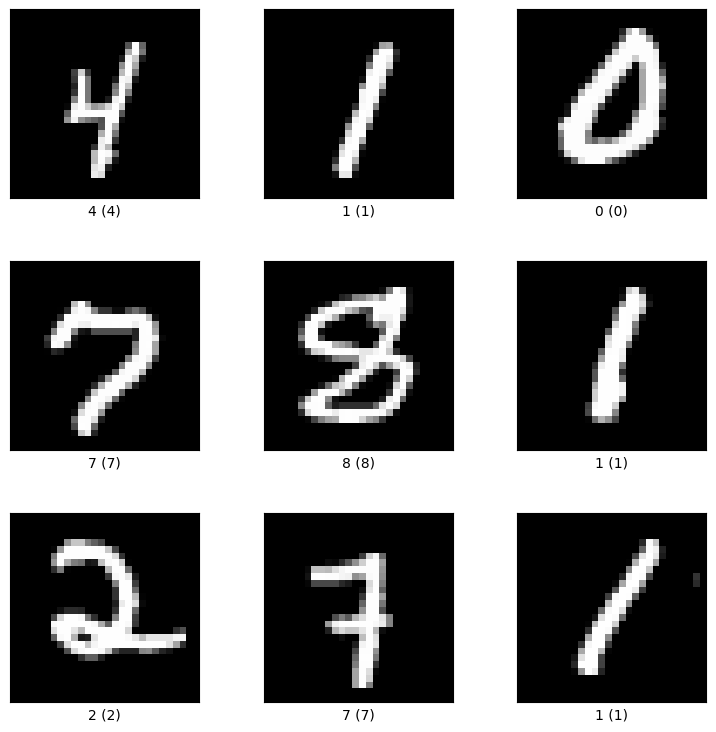

In [105]:
fig = tfds.show_examples(mnist_train, ds_info)

## Map method

When using the `Dataset.map` (and `Dataset.filter`) transformations we apply a function to each element of the `Dataset`.
Then we batch and shuffle the `Dataset` and we levergae the call to `prefetch`.

This allows later elements to be prepared while the current element is being processed. This often improves latency and throughput, at the cost of using additional memory to store prefetched elements.

In [106]:
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 10, name='label', axis=-1)

mnist_train = mnist_train.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_train = mnist_train.cache()
mnist_train = mnist_train.shuffle(ds_info.splits['train'].num_examples)
mnist_train = mnist_train.batch(128)
mnist_train = mnist_train.prefetch(tf.data.AUTOTUNE)

mnist_test = mnist_test.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_test = mnist_test.cache()
mnist_test = mnist_test.batch(128)
mnist_test = mnist_test.prefetch(tf.data.AUTOTUNE)
# shuffling during testing doesn't change the model's accuracy, so we skip it to save time and memory.

# Model building (the hard way)

Here we build a 2-hidden layers fully connected neural network leveraging a **low-level** approach to better understand all mechanics behind building neural networks and the training process.

In [107]:
# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
n_hidden_2 = 256 # 2nd layer number of neurons.

# Training parameters.
learning_rate = 0.1
training_steps = 2000
display_step = 100

## Create TF Model

In [108]:
class NeuralNet(tf.keras.Model):
    # Set layers.
    def __init__(self):
        super(NeuralNet, self).__init__()
        # First fully-connected hidden layer.
        self.fc1 = tf.keras.layers.Dense(n_hidden_1, activation=tf.nn.relu)
        # Second fully-connected hidden layer.
        self.fc2 = tf.keras.layers.Dense(n_hidden_2, activation=tf.nn.relu)
        # Output layer.
        self.out = tf.keras.layers.Dense(num_classes)

    # Set forward pass.
    def call(self, x, is_training=False):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.out(x)
        if not is_training:
            # tf cross entropy expect logits without softmax, so only
            # apply softmax when not training.
            x = tf.nn.softmax(x)
        return x

# Build neural network model.
neural_net = NeuralNet()

## Metrics definition

In [109]:
# Note that this will apply 'softmax' to the logits.
def cross_entropy_loss(x, y):
    # Convert labels to int 64 for tf cross-entropy function.
    y = tf.cast(y, tf.int64)
    # Apply softmax to logits and compute cross-entropy.
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=x)
    # Average loss across the batch.
    return tf.reduce_mean(loss)

# Accuracy metric.
def accuracy(y_pred, y_true):
    # Predicted class is the index of highest score in prediction vector (i.e. argmax).
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis=-1)

# Stochastic gradient descent optimizer.
optimizer = tf.optimizers.SGD(learning_rate)

## Optimization definition

In [110]:
def run_optimization(x, y):
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        # Forward pass.
        pred = neural_net(x, is_training=True)
        # Compute loss.
        loss = cross_entropy_loss(pred, y)

    # Variables to update, i.e. trainable variables.
    trainable_variables = neural_net.trainable_variables

    # Compute gradients.
    gradients = g.gradient(loss, trainable_variables)

    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, trainable_variables))

## Run the training for the given number of steps.

In [111]:
# Run training
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Run the optimization to update W and b values.
    run_optimization(batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x, is_training=True)
        loss = cross_entropy_loss(pred, batch_y)
        acc = accuracy(pred, batch_y)
        print("step: %i, loss: %f, accuracy: %f" % (step, loss, acc))

step: 100, loss: 0.348768, accuracy: 0.921875
step: 200, loss: 0.306366, accuracy: 0.906250
step: 300, loss: 0.259099, accuracy: 0.945312
step: 400, loss: 0.177347, accuracy: 0.945312
step: 500, loss: 0.231131, accuracy: 0.960938
step: 600, loss: 0.127742, accuracy: 0.968750
step: 700, loss: 0.140722, accuracy: 0.953125
step: 800, loss: 0.209265, accuracy: 0.937500
step: 900, loss: 0.082731, accuracy: 0.968750
step: 1000, loss: 0.090209, accuracy: 0.968750
step: 1100, loss: 0.087518, accuracy: 0.984375
step: 1200, loss: 0.063846, accuracy: 1.000000
step: 1300, loss: 0.078210, accuracy: 0.992188
step: 1400, loss: 0.097564, accuracy: 0.960938
step: 1500, loss: 0.073425, accuracy: 0.984375
step: 1600, loss: 0.062002, accuracy: 0.984375
step: 1700, loss: 0.091124, accuracy: 0.984375
step: 1800, loss: 0.081356, accuracy: 0.984375
step: 1900, loss: 0.089779, accuracy: 0.976562
step: 2000, loss: 0.108940, accuracy: 0.976562


## Test and plot some predictions

In [112]:
# Test model on validation set.
pred = neural_net(x_test, is_training=False)
print("Test Accuracy: %f" % accuracy(pred, y_test))

Test Accuracy: 0.962300


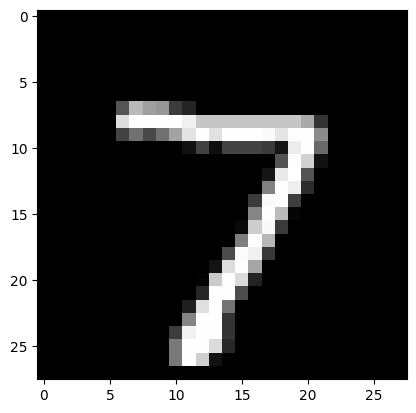

Model prediction: 7


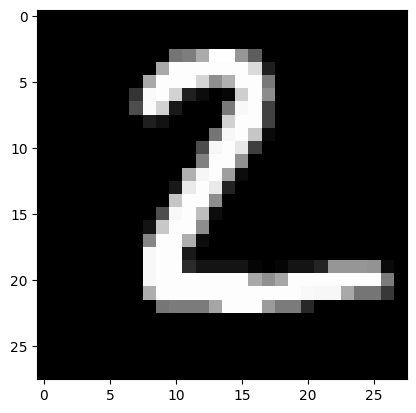

Model prediction: 2


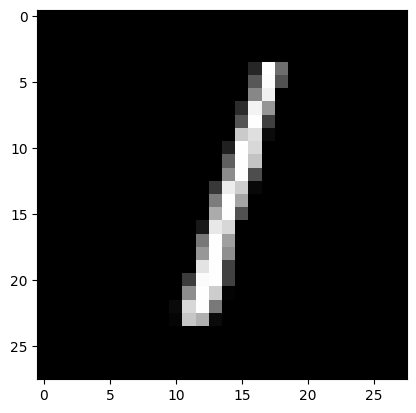

Model prediction: 1


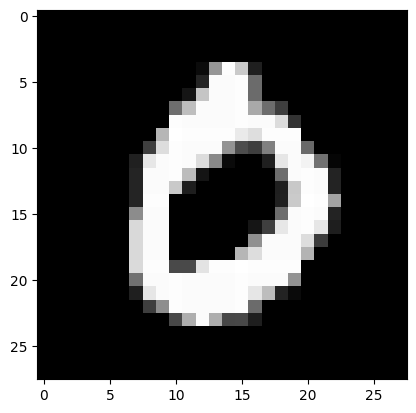

Model prediction: 0


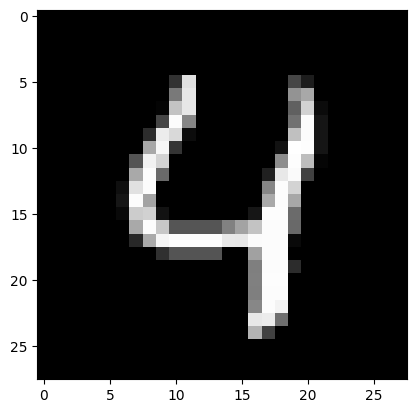

Model prediction: 4


In [113]:
# Predict 5 images from validation set.
n_images = 5
test_images = x_test[:n_images]
predictions = neural_net(test_images)

# Display image and model prediction.
for i in range(n_images):
    plt.imshow(np.reshape(test_images[i], [28, 28]), cmap='gray')
    plt.show()
    print("Model prediction: %i" % np.argmax(predictions.numpy()[i]))

# Model building (the easy way)

##  [Sequential model](https://keras.io/api/models/sequential/)

Note that, since we will now leverage a ready-to-use loss in tf (namely, tf.keras.losses.CategoricalCrossentropy()) we need to encode in one-hot the labels.

In [114]:
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.shuffle(5000).batch(batch_size).prefetch(1)

In [115]:
test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_data = test_data.batch(batch_size).prefetch(1)

In [116]:
def process_data(image, label):
    return image, tf.one_hot(label, 10, name='label', axis=-1)

In [117]:
train_data = train_data.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)

In [118]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(n_hidden_1, activation='relu'))
model.add(tf.keras.layers.Dense(n_hidden_2, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

## defining the optimiser and loss function
model.compile(optimizer=tf.optimizers.SGD(learning_rate),
              metrics=["accuracy"],
              loss=tf.keras.losses.CategoricalCrossentropy())

## training the model
model.fit(train_data,
          batch_size=128,
          epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8697 - loss: 0.4637
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9370 - loss: 0.2188
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9528 - loss: 0.1636
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9617 - loss: 0.1317
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9682 - loss: 0.1098
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9730 - loss: 0.0934
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9762 - loss: 0.0806
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0706
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9811 - loss: 0.0630
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0563


In [119]:
print(f"Accuracy: {model.evaluate(test_data)[1]:.2f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9742 - loss: 0.0830
Accuracy: 0.97


##[Model API (ex functional)](https://keras.io/api/models/model/#model-class)

In [120]:
input_layer = tf.keras.layers.Input(shape=(num_features,))
layer_1 = tf.keras.layers.Dense(n_hidden_1, activation="relu")(input_layer)
layer_2 = tf.keras.layers.Dense(n_hidden_2, activation="relu")(layer_1)
output_layer= tf.keras.layers.Dense(num_classes, activation="softmax")(layer_2)

## Defining the model by specifying the input and output layers
model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

## defining the optimiser and loss function
model.compile(optimizer=tf.optimizers.SGD(learning_rate),
              metrics=["accuracy"],
              loss=tf.keras.losses.CategoricalCrossentropy())

## training the model
history = model.fit(train_data,
                    batch_size=128,
                    epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8699 - loss: 0.4618
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9344 - loss: 0.2235
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9510 - loss: 0.1676
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9617 - loss: 0.1333
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.1100
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0937
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0816
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9796 - loss: 0.0714
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0632
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9837 - loss: 0.0574


In [121]:
print(f"Accuracy: {model.evaluate(test_data)[1]:.2f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9748 - loss: 0.0856
Accuracy: 0.97


# Assignment #1: making new Layers and Models via subclassing
You will build a ResNet18 architecture leveraging tf.keras.Model subclassing



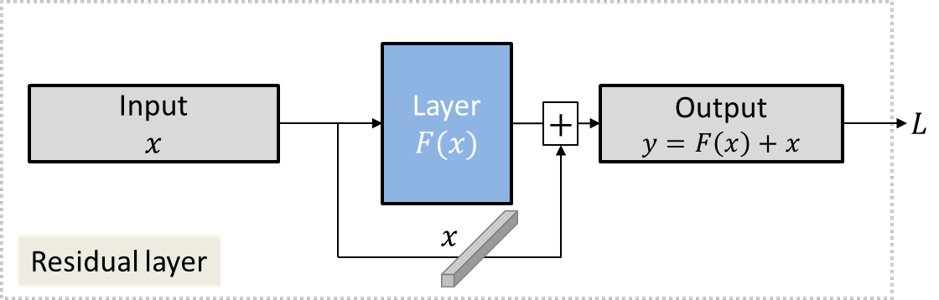

Notes:
*   **Batch normalization** is implemented right after each convolution and before activation
*   If the **input dimension has the same dimension as the output** the block implements an identity function
*   **Otherwise** in the skip connection we insert a 1x1 convolutional block

In [122]:
class Residual(tf.keras.Model):
    """The Residual block of ResNet."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            num_channels,
            padding='same',
            kernel_size=3,
            strides=strides)
        self.conv2 = tf.keras.layers.Conv2D(
            num_channels,
            kernel_size=3,
            padding='same')
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

In [123]:
class ResnetBlock(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlock, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(Residual(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

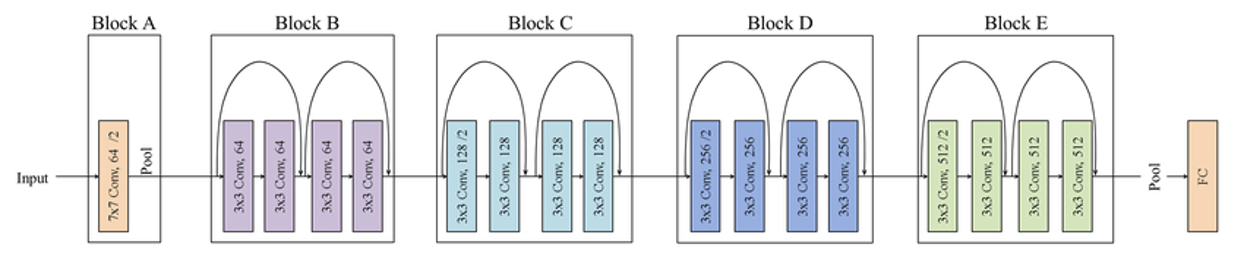

## ResNet18

In [124]:
class ResNet(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

# Assignment #2: the CIFAR-10
1. Load the CIFAR-10 from TFDS (see [here](https://www.tensorflow.org/datasets/catalog/cifar10))
2. Train and test your ResNet18 on such dataset


In [125]:
num_classes = 10
num_features = 1024 # 32 * 32
batch_size = 128

# # Get the data in form of numpy array
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# print(x_train.shape)
# print(y_train.shape)
# print(x_test.shape)
# print(y_test.shape)

# # Convert to float32 ND Normalize images value from [0, 255] to [0, 1].
# x_train, x_test = x_train.astype(np.float32) / 255., x_test.astype(np.float32) / 255.

In [126]:
(cifar10_train, cifar10_test), ds_info = tfds.load(
    'cifar10',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

In [127]:
print(cifar10_train)
print(cifar10_test)

<_PrefetchDataset element_spec=(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


,image,label
0,,7 (horse)
1,,8 (ship)
2,,4 (deer)
3,,4 (deer)

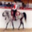
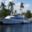
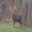
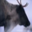

In [128]:
tfds.as_dataframe(cifar10_train.take(4), ds_info)

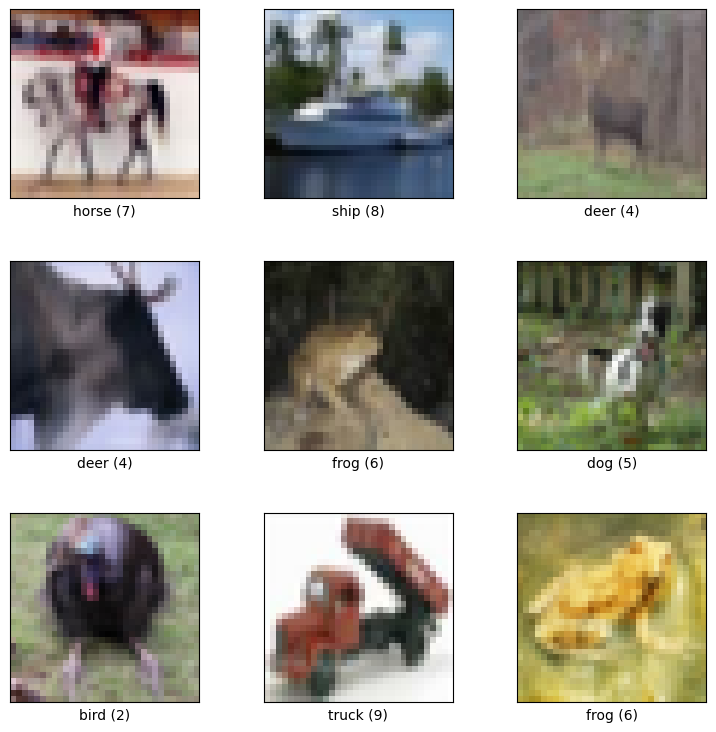

In [129]:
fig = tfds.show_examples(cifar10_train, ds_info)

In [130]:
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., label

cifar10_train = cifar10_train.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
cifar10_train = cifar10_train.cache()
cifar10_train = cifar10_train.shuffle(ds_info.splits['train'].num_examples)
cifar10_train = cifar10_train.batch(batch_size)
cifar10_train = cifar10_train.prefetch(tf.data.AUTOTUNE)

cifar10_test = cifar10_test.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
cifar10_test = cifar10_test.cache()
cifar10_test = cifar10_test.batch(batch_size)
cifar10_test = cifar10_test.prefetch(tf.data.AUTOTUNE)


In [133]:
IMAGE_SIZE = 32
net = ResNet()
net.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))

net.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

net.fit(
    cifar10_train,
    epochs=15,
    validation_data=cifar10_test
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.3827 - loss: 1.6527 - val_accuracy: 0.4998 - val_loss: 1.3628
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5424 - loss: 1.2610 - val_accuracy: 0.5839 - val_loss: 1.1687
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6200 - loss: 1.0658 - val_accuracy: 0.6228 - val_loss: 1.0988
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6727 - loss: 0.9267 - val_accuracy: 0.6550 - val_loss: 1.0054
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7116 - loss: 0.8127 - val_accuracy: 0.6755 - val_loss: 0.9317
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7577 - loss: 0.6907 - val_accuracy: 0.6862 - val_loss: 0.9361
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7921 - loss: 0.5916 - val_accuracy: 0.6987 - val_loss: 0.9221
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8276 - loss: 0.4907 - val_accuracy: 0.6

In [134]:
print(f"Accuracy: {net.evaluate(cifar10_test)[1]:.2f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6966 - loss: 1.4724
Accuracy: 0.70
